This is the final version that we used for the experiments in the CDC paper.

- It has the small compact architecture: Encoding, MLP, score-attention for Actor network, and then MLP, pooling layer, and MLP again for the Critic network.
- Minimum arrival rate is considered to be 0.05 to make sure no queue is left out without arrivals.

In [10]:
import time
import numpy as np
from typing import Dict, Any, List, Optional, Callable
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.preprocessing import preprocess_obs
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize
from stable_baselines3.common.utils import set_random_seed
from stable_baselines3 import PPO
from stable_baselines3.common.distributions import MultiCategoricalDistribution
import os
from stable_baselines3.common.callbacks import BaseCallback
from collections import deque


class QueueEnv(gym.Env):
    """
    Multi-robot, multi-queue env with switching delay = 1.
    Actions per robot: which queue to go to next (including current).
    Observation: dict(robots: positions, queues: lengths).
    Reward: -sum(queues).
    """
    metadata = {"render_modes": []}

    def __init__(self,
             M: int = 2,
             N: int = 4,
             arrival_params=None,
             queue_cost_weights=None,
             seed: Optional[int] = None,
             lambda_collision: float = 0.0,
             max_steps_per_run: Optional[int] = None,
             max_queue_length: int = 50,
             barrier_start: float = 0.8,
             alpha: float = 20,
             ):
        super().__init__()
        self.M, self.N = M, N
        self.lambda_collision = float(lambda_collision)
        self.max_steps_per_run = max_steps_per_run                 # <<< NEW
        self.barrier_start = barrier_start * max_queue_length      # <<< NEW
        self.alpha = alpha

        if arrival_params is None:
            arrival_params = np.full(N, 0.10, dtype=np.float32)
        self.arrival_params = np.asarray(arrival_params, dtype=np.float32)

        if queue_cost_weights is None:
            queue_cost_weights = np.ones(N, dtype=np.float32)
        self.queue_cost_weights = np.asarray(queue_cost_weights, dtype=np.float32)

        assert self.queue_cost_weights.shape == (N,), \
            f"queue_cost_weights must have shape ({N},), got {self.queue_cost_weights.shape}"

        # RNG and step counter
        self._seed = None
        self.rng = np.random.default_rng(seed)
        self._step_count = 0                                       # <<< NEW

        # State
        self._queues = np.zeros(self.N, dtype=np.float32)
        self._robots = np.arange(self.M, dtype=np.int64)

        # Spaces
        self.observation_space = spaces.Dict({
            "robots": spaces.MultiDiscrete([N] * M),
            "queues": spaces.Box(low=0, high=max_queue_length, shape=(N,), dtype=np.float32)
        })
        self.action_space = spaces.MultiDiscrete([N] * M)

    def _get_obs(self):
        return {"robots": self._robots.copy(), "queues": self._queues.copy()}

    def reset(self, *, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None):
        # Gymnasium seeding API
        if seed is not None:
            self._seed = int(seed)
            self.rng = np.random.default_rng(self._seed)
        self._step_count = 0                                       # <<< reset counter
        self._queues.fill(0.0)
        self._robots = np.arange(self.M, dtype=np.int64)
        obs = self._get_obs()
        info: Dict[str, Any] = {}
        return obs, info

    def _resolve_collisions(self, intended_pos):
        # Reserve all current positions initially
        final_pos = self._robots.copy()
        taken = set(final_pos.tolist())

        projected = 0
        for r in range(self.M):
            tgt = int(intended_pos[r])
            cur = int(self._robots[r])

            if tgt == cur:
                # Stayer: already reserved; nothing to do
                continue

            if tgt not in taken:
                # Move succeeds: free old spot, claim target
                final_pos[r] = tgt
                taken.remove(cur)
                taken.add(tgt)
            else:
                # Move fails: stay; count projection
                projected += 1
                # final_pos[r] already equals cur; 'taken' unchanged

        return final_pos, projected

    def step(self, action: np.ndarray):
        action = np.asarray(action, dtype=np.int64)
        assert action.shape == (self.M,), f"Expected action shape {(self.M,)}, got {action.shape}"

        # --- snapshot BEFORE
        queues_before = self._queues.copy()
        robots_before = self._robots.copy()

        # --- reward from current queues (pre-cost)
        qsmean = float(self._queues.mean())
        # # --- NEW: weighted queue cost and diagnostics
        # qsmean = float(np.dot(self.queue_cost_weights, self._queues) / self.N)

        # penalty_cap = self.alpha * np.sum(np.maximum(0.0, (self._queues - self.barrier_start) / (self.observation_space["queues"].high[0] - self.barrier_start)) ** 2)
        # reward = -float(self._queues.sum()) - penalty_cap
        weighted_cost = float(np.dot(self.queue_cost_weights, queues_before))
        reward = -weighted_cost

        action = np.asarray(action, dtype=np.int64)
        stay_mask = (action == robots_before).astype(np.int64)
        switch_mask = (action != robots_before).astype(np.int64)

        # --- serve (record who actually served)
        served_mask = np.zeros(self.M, dtype=np.int64)
        for r in range(self.M):
            loc = int(self._robots[r])
            if action[r] == loc and self._queues[loc] > 0:
                self._queues[loc] -= 1.0
                served_mask[r] = 1

        empty_stay_mask = np.zeros(self.M, dtype=np.int64)
        for r in range(self.M):
            loc = int(robots_before[r])
            if stay_mask[r] == 1 and queues_before[loc] <= 0:
                empty_stay_mask[r] = 1

        # --- switch intentions
        intended = self._robots.copy()
        for r in range(self.M):
            intended[r] = action[r]

        # --- apply collision resolution
        new_pos, num_proj = self._resolve_collisions(intended)
        self._robots = new_pos

        # --- arrivals
        p = self.arrival_params
        arrivals = self.rng.binomial(n=1, p=p, size=self.N).astype(np.float32)

        qmax = float(self.observation_space["queues"].high[0])
        room = np.maximum(0.0, qmax - self._queues)
        admitted = np.minimum(arrivals, room)
        dropped = arrivals - admitted

        self._queues = self._queues + admitted

        # --- collision penalty
        if self.lambda_collision > 0 and num_proj > 0:
            reward -= self.lambda_collision * float(num_proj)

        # --- truncation logic
        self._step_count += 1
        truncated = (
            self.max_steps_per_run is not None
            and self._step_count >= self.max_steps_per_run
        )
        terminated = False
        obs = self._get_obs()
        # print(f"queues_mean: {qsmean}, collisions: {int(num_proj)}")  # <<< DEBUG PRINT
        
        cap_count = int((self._queues >= self.observation_space["queues"].high[0] - 1e-8).sum())
        any_cap = int(cap_count > 0)

        info: Dict[str, Any] = {
            "queues_mean": qsmean,
            "collisions_count": int(num_proj),

            # diagnostics
            "stay_count": int(stay_mask.sum()),
            "switch_count": int(switch_mask.sum()),
            "served_count": int(served_mask.sum()),
            "empty_stay_count": int(empty_stay_mask.sum()),
            "cap_count": cap_count,
            "any_cap": any_cap,

            # truncation diagnostics
            "lost_arrivals_count": int(dropped.sum()),
            "weighted_lost_arrivals": float(np.dot(self.queue_cost_weights, dropped)),
        }

        # # --- TRACE: rich info for debugging/analysis
        # info: Dict[str, Any] = {
        #     "queues_before": queues_before,
        #     "robots_before": robots_before,
        #     "action_array": action.copy(),
        #     "served_mask": served_mask,
        #     "intended_positions": intended,
        #     "robots_after": self._robots.copy(),
        #     "arrivals": arrivals,
        #     "num_projections": int(num_proj),
        #     "cost_pre": cost_pre,
        #     "reward": reward,
        #     "truncated": truncated,
        # }
        
        return obs, reward, terminated, truncated, info

In [ ]:
class CTDECritic(nn.Module):
    """
    Simple centralized pooled critic.
    Permutation-friendly over queues and robots.
    No queue-id embeddings, no urgency subnet.
    """
    def __init__(
        self,
        N,
        M,
        queue_cost_weights,
        d_model=128,
        d_robot_emb=16,
        max_q_cap=100.0,
        rate_scale=1.0,
        weight_scale=1.0,
    ):
        super().__init__()
        self.N = N
        self.M = M
        self.max_q_cap = float(max_q_cap)
        self.rate_scale = float(rate_scale)
        self.weight_scale = float(weight_scale)

        qcw = torch.as_tensor(queue_cost_weights, dtype=torch.float32)
        self.register_buffer("queue_cost_weights", qcw)

        self.robot_emb = nn.Embedding(num_embeddings=N, embedding_dim=d_robot_emb)

        # queue features:
        # q, lambda, w, q*w, occupied_now
        self.queue_enc = nn.Sequential(
            nn.Linear(5, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
        )

        # robot features:
        # robot-location embedding + local q, lambda, w, busy
        self.robot_enc = nn.Sequential(
            nn.Linear(d_robot_emb + 4, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
        )

        # pooled critic head
        self.value_head = nn.Sequential(
            nn.Linear(2 * d_model + 4, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1),
        )

    def forward(self, obs, rates):
        queues = obs["queues"].float()   # [B,N]
        robots = obs["robots"].long()    # [B,M]
        B, N, M = queues.shape[0], self.N, self.M
        dev = queues.device

        if rates.dim() == 1:
            rates_b = rates.view(1, N).expand(B, N)
        else:
            rates_b = rates

        w = self.queue_cost_weights.view(1, N).expand(B, N).to(dev)

        q_norm = queues / max(self.max_q_cap, 1.0)
        lam_norm = rates_b / max(self.rate_scale, 1e-8)
        w_norm = w / max(self.weight_scale, 1e-8)
        qw_norm = q_norm * w_norm

        occ = torch.zeros(B, N, device=dev)
        occ.scatter_add_(1, robots, torch.ones(B, M, device=dev))
        occ = (occ > 0).float()

        q_feats = torch.stack([q_norm, lam_norm, w_norm, qw_norm, occ], dim=-1)  # [B,N,5]
        q_tokens = self.queue_enc(q_feats)                                         # [B,N,d]

        q_here = q_norm.gather(1, robots)      # [B,M]
        lam_here = lam_norm.gather(1, robots)  # [B,M]
        w_here = w_norm.gather(1, robots)      # [B,M]
        busy = (queues.gather(1, robots) > 0).float()

        r_emb = self.robot_emb(robots)         # [B,M,d_robot_emb]
        r_feats = torch.cat(
            [r_emb, q_here.unsqueeze(-1), lam_here.unsqueeze(-1), w_here.unsqueeze(-1), busy.unsqueeze(-1)],
            dim=-1
        )                                      # [B,M,d_robot_emb+4]
        r_tokens = self.robot_enc(r_feats)     # [B,M,d]

        q_pool = q_tokens.mean(dim=1)          # [B,d]
        r_pool = r_tokens.mean(dim=1)          # [B,d]

        globals_ = torch.stack(
            [
                qw_norm.sum(dim=1),               # total weighted normalized backlog
                qw_norm.max(dim=1).values,        # largest weighted normalized queue
                q_norm.mean(dim=1),               # mean normalized queue
                (1.0 - busy).mean(dim=1),         # idle fraction
            ],
            dim=-1
        )                                       # [B,4]

        value = self.value_head(torch.cat([q_pool, r_pool, globals_], dim=-1)).squeeze(-1)
        return value


class RobotQueueAttentionActor(nn.Module):
    """
    Assignment-only actor.

    Busy robots are FORCED to stay.
    Idle robots receive learned logits over queues.
    Distinct-destination masking across robots is still handled by the
    existing SB3 autoregressive sampler/evaluator in QueuePPOPolicy.

    No queue-id embedding. Shared queue scorer restores permutation symmetry.
    """
    def __init__(
        self,
        N,
        M,
        queue_cost_weights,
        d_model=128,
        d_robot_emb=16,
        max_q_cap=100.0,
        rate_scale=1.0,
        weight_scale=1.0,
    ):
        super().__init__()
        self.N = N
        self.M = M
        self.max_q_cap = float(max_q_cap)
        self.rate_scale = float(rate_scale)
        self.weight_scale = float(weight_scale)
        self.score_temp = float(d_model) ** 0.5

        qcw = torch.as_tensor(queue_cost_weights, dtype=torch.float32)
        self.register_buffer("queue_cost_weights", qcw)

        self.robot_emb = nn.Embedding(num_embeddings=N, embedding_dim=d_robot_emb)

        # queue features:
        # q, lambda, w, q*w, occupied_now, free_now
        self.queue_enc = nn.Sequential(
            nn.Linear(6, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
        )

        # robot features:
        # robot-location embedding + local q, lambda, w, busy
        self.robot_enc = nn.Sequential(
            nn.Linear(d_robot_emb + 4, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
        )

        self.queue_bias = nn.Linear(d_model, 1, bias=False)
        self.idle_self_bias = nn.Parameter(torch.zeros(1))

    def forward(self, obs, rates_b):
        queues = obs["queues"].float()     # [B,N]
        robots = obs["robots"].long()      # [B,M]
        B, N, M = queues.shape[0], self.N, self.M
        dev = queues.device

        w = self.queue_cost_weights.view(1, N).expand(B, N).to(dev)

        q_norm = queues / max(self.max_q_cap, 1.0)
        lam_norm = rates_b.float() / max(self.rate_scale, 1e-8)
        w_norm = w / max(self.weight_scale, 1e-8)
        qw_norm = q_norm * w_norm

        occ = torch.zeros(B, N, device=dev)
        occ.scatter_add_(1, robots, torch.ones(B, M, device=dev))
        occ_bool = occ > 0
        occ_float = occ_bool.float()

        q_feats = torch.stack(
            [q_norm, lam_norm, w_norm, qw_norm, occ_float, 1.0 - occ_float],
            dim=-1
        )                                          # [B,N,6]
        q_tokens = self.queue_enc(q_feats)         # [B,N,d]
        q_bias = self.queue_bias(q_tokens).squeeze(-1)  # [B,N]

        q_here = q_norm.gather(1, robots)          # [B,M]
        lam_here = lam_norm.gather(1, robots)      # [B,M]
        w_here = w_norm.gather(1, robots)          # [B,M]
        busy = (queues.gather(1, robots) > 0)      # [B,M] bool

        r_emb = self.robot_emb(robots)             # [B,M,d_robot_emb]
        r_feats = torch.cat(
            [r_emb, q_here.unsqueeze(-1), lam_here.unsqueeze(-1), w_here.unsqueeze(-1), busy.float().unsqueeze(-1)],
            dim=-1
        )                                          # [B,M,d_robot_emb+4]
        r_tokens = self.robot_enc(r_feats)         # [B,M,d]

        # Pairwise robot-queue scores
        scores = torch.einsum("bmd,bnd->bmn", r_tokens, q_tokens) / self.score_temp
        scores = scores + q_bias[:, None, :]

        self_loc = F.one_hot(robots, num_classes=N).bool()                 # [B,M,N]

        # Current-occupancy feasibility:
        # queue must be currently free, unless robot stays at its own location
        allow_now = (~occ_bool).unsqueeze(1).expand(B, M, N) | self_loc
        scores = scores.masked_fill(~allow_now, -1e9)

        # Small stay bias only for idle robots
        scores = scores + self.idle_self_bias * self_loc.float()

        # FORCE busy robots to stay (exhaustive structure)
        forced_logits = torch.full_like(scores, -1e9)
        forced_logits.scatter_(2, robots.unsqueeze(-1), 0.0)
        scores = torch.where(busy.unsqueeze(-1), forced_logits, scores)

        return scores


class QueuePolicyNet_Attn(nn.Module):
    """
    New policy net:
      - assignment-only actor
      - pooled centralized critic
      - no urgency subnetwork
      - no queue-id embedding
    """
    def __init__(
        self,
        M,
        N,
        d_r=16,
        arrival_rates=None,
        queue_cost_weights=None,
        max_queue_length=100,
        actor_d_model=128,
        critic_d_model=128,
    ):
        super().__init__()
        self.M, self.N, self.d_r = M, N, d_r

        rates = torch.as_tensor(arrival_rates, dtype=torch.float32)
        qcw = torch.as_tensor(queue_cost_weights, dtype=torch.float32)

        self.register_buffer("rates", rates)
        self.register_buffer("queue_cost_weights", qcw)

        rate_scale = float(rates.max().item()) if rates.numel() > 0 else 1.0
        weight_scale = float(qcw.max().item()) if qcw.numel() > 0 else 1.0
        max_q_cap = float(max_queue_length)

        self.actor_attn = RobotQueueAttentionActor(
            N=N,
            M=M,
            queue_cost_weights=qcw,
            d_model=actor_d_model,
            d_robot_emb=d_r,
            max_q_cap=max_q_cap,
            rate_scale=rate_scale,
            weight_scale=weight_scale,
        )

        self.critic = CTDECritic(
            N=N,
            M=M,
            queue_cost_weights=qcw,
            d_model=critic_d_model,
            d_robot_emb=d_r,
            max_q_cap=max_q_cap,
            rate_scale=rate_scale,
            weight_scale=weight_scale,
        )

    def forward(self, obs):
        queues = obs["queues"].float()
        B = queues.shape[0]
        N = self.N

        rates_b = self.rates.view(1, N).expand(B, N)

        logits = self.actor_attn(obs, rates_b)   # [B,M,N]
        value = self.critic(obs, self.rates)     # [B]
        return logits, value

class QueuePPOPolicy(ActorCriticPolicy):
    def __init__(
        self,
        observation_space,
        action_space,
        lr_schedule,
        arrival_rates,
        queue_cost_weights,
        max_queue_length,
        **kwargs
    ):
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

        self.M = int(len(action_space.nvec))
        self.N = int(action_space.nvec[0])

        arrival_rates = torch.as_tensor(arrival_rates, dtype=torch.float32, device=self.device)
        queue_cost_weights = torch.as_tensor(queue_cost_weights, dtype=torch.float32, device=self.device)

        self.net = QueuePolicyNet_Attn(
            M=self.M,
            N=self.N,
            d_r=16,
            arrival_rates=arrival_rates,
            queue_cost_weights=queue_cost_weights,
            max_queue_length=max_queue_length,
            actor_d_model=128,
            critic_d_model=128,
        )

        self._action_dims = action_space.nvec.tolist()
        self._dist = MultiCategoricalDistribution(self._action_dims)
        self.optimizer = self.optimizer_class(
            self.parameters(),
            lr=lr_schedule(1),
            **self.optimizer_kwargs
        )

    # === IMPORTANT: provide a dummy mlp_extractor so SB3 is happy ===
    def _build_mlp_extractor(self) -> None:
        class _Bypass(nn.Module):
            def __init__(self):
                super().__init__()
                # SB3 looks for these two attributes to size default heads;
                # we give harmless nonzero placeholders.
                self.latent_dim_pi = 1
                self.latent_dim_vf = 1
            def forward(self, features: torch.Tensor):
                # Not used by our policy; return dummy tensors with correct batch dim
                b = features.shape[0] if features.ndim > 0 else 1
                z = torch.zeros((b, 1), device=features.device, dtype=features.dtype)
                return z, z
        self.mlp_extractor = _Bypass()

    def sample_autoreg_and_logp(self, logits, robots, deterministic: bool):
        """
        logits: [B, M, N]  (raw per-robot logits from actor)
        robots: [B, M]     (current robot locations)
        Returns:
        actions: [B, M]
        logp:    [B]
        """
        B, M, N = logits.shape
        dev = logits.device

        occ = torch.zeros(B, N, dtype=torch.bool, device=dev)  # occupied by earlier robots
        actions = torch.empty(B, M, dtype=torch.long, device=dev)
        logp = torch.zeros(B, device=dev)

        for r in range(M):
            # allow: unoccupied OR own location (staying is always allowed)
            self_loc = F.one_hot(robots[:, r], num_classes=N).bool()      # [B, N]
            allow = (~occ) | self_loc                                     # [B, N]

            logits_r = logits[:, r, :].masked_fill(~allow, -1e9)          # [B, N]
            dist_r = Categorical(logits=logits_r)

            if deterministic:
                a_r = torch.argmax(logits_r, dim=-1)
            else:
                a_r = dist_r.sample()

            actions[:, r] = a_r
            logp = logp + dist_r.log_prob(a_r)

            # mark chosen destination as occupied for later robots
            occ.scatter_(1, a_r[:, None], True)

        return actions, logp
    
    def autoreg_logp_of_actions(self, logits, robots, actions):
        """
        Compute log pi(actions|obs) under the same autoregressive masking rule.
        logits:  [B, M, N]
        robots:  [B, M]
        actions: [B, M]
        Returns:
        logp: [B]
        """
        B, M, N = logits.shape
        dev = logits.device
        occ = torch.zeros(B, N, dtype=torch.bool, device=dev)
        logp = torch.zeros(B, device=dev, dtype=logits.dtype)

        actions = actions.long()
        robots = robots.long()

        for r in range(M):
            a_r = actions[:, r].long()
            self_loc = F.one_hot(robots[:, r], num_classes=N).bool()
            logits_r = logits[:, r, :].clone()
            allow = (~occ) | self_loc
            logits_r = logits_r.masked_fill(~allow, -1e9)
            dist_r = Categorical(logits=logits_r)
            logp = logp + dist_r.log_prob(a_r)
            occ.scatter_(1, a_r[:, None], True)

        return logp

    def forward(self, obs, deterministic: bool = False):
        """
        Return: action [B, M], value [B], log_prob [B]
        Uses SB3's MultiCategoricalDistribution so that .predict() and training paths agree.
        """
        logits, value = self.net(obs)                     # [B, M, N], [B]
        robots = obs['robots'].long()                     # [B, M]
        # B = logits.shape[0]
        ## Flatten per-robot logits for MultiCategoricalDistribution: [B, sum(nvec)] = [B, M*N]
        # logits_flat = logits.view(B, -1)
        # dist = self._dist.proba_distribution(logits_flat)
        # action = dist.get_actions(deterministic=deterministic)   # [B, M]
        # log_prob = dist.log_prob(action)                         # [B]
        action, log_prob = self.sample_autoreg_and_logp(logits, robots, deterministic)   # [B, M], [B]
        
        return action, value, log_prob
    
    def _predict(self, observation, deterministic: bool = False):
        """
        SB3 calls this inside model.predict().
        observation: torch.Tensor or dict of torch.Tensor (SB3 already tensorizes obs)
        Return: actions as torch.LongTensor [B, M]
        """
        logits, _ = self.net(observation)          # [B, M, N]
        robots = observation["robots"].long()      # [B, M]
        actions, _ = self.sample_autoreg_and_logp(logits, robots, deterministic)
        return actions

    # SB3 uses this during updates to rebuild the distribution
    def get_distribution(self, obs):
        """
        Build an SB3 MultiCategoricalDistribution from the network logits.
        Returns an object with .get_actions(), .log_prob(), .entropy().
        """
        logits, _ = self.net(obs)               # [B, M, N]
        B = logits.shape[0]
        logits_flat = logits.view(B, -1)        # [B, sum(nvec)]
        return self._dist.proba_distribution(logits_flat)
        # action, log_prob = self.sample_autoreg_and_logp(logits, robots, deterministic)   # [B, M], [B]
        # return lo

    def predict_values(self, obs):
        """
        Get the estimated values according to the current policy.
        :param obs:
        :return: the estimated values.
        """
        # Pass the dictionary observation directly to the network's forward_critic
        return self.forward_critic(obs)


    # Used in PPO training loop to compute log-probs/entropy on minibatches
    def evaluate_actions(self, obs, actions):
        """
        obs: dict batch (from rollout buffer)
        actions: LongTensor of shape [batch, M]
        Return: values [batch], log_prob [batch], entropy [batch]
        """
        logits, value = self.net(obs)                   # [B, M, N], [B]
        # B = logits.shape[0]
        # logits_flat = logits.view(B, -1)              # [B, sum(nvec)]
        # dist = self._dist.proba_distribution(logits_flat)
        # log_prob = dist.log_prob(actions)             # [B]
        # entropy = dist.entropy()                      # [B]
        # return value, log_prob, entropy
        robots = obs['robots'].long()                     # [B, M]
        log_prob = self.autoreg_logp_of_actions(logits, robots, actions)  # [B]
        # Entropy of an AR policy is sum of entropies of each conditional.
        # We compute it along the same realized occupancy trajectory induced by 'actions'.
        B, M, N = logits.shape
        dev = logits.device
        occ = torch.zeros(B, N, dtype=torch.bool, device=dev)
        self_loc = F.one_hot(robots, num_classes=N).bool()

        entropy = torch.zeros(B, dtype=torch.float32, device=dev)
        for r in range(M):
            allow_r = (~occ) | self_loc[:, r, :]
            logits_r = logits[:, r, :].clone()
            logits_r = logits_r.masked_fill(~allow_r, -1e9)
            dist_r = Categorical(logits=logits_r)
            entropy += dist_r.entropy()
            a_r = actions[:, r].long()
            occ.scatter_(1, a_r[:, None], True)

        return value, log_prob, entropy

    # Optional, used by SB3 in some code paths
    def forward_actor(self, obs):
        logits, _ = self.net(obs)
        return logits

    def forward_critic(self, obs):
        _, value = self.net(obs)
        return value

In [13]:
import numpy as np
from typing import Dict, Callable


def make_weighted_greedy_no_collision(
    arrival_rates: np.ndarray,
    queue_cost_weights: np.ndarray,
) -> Callable[[Dict[str, np.ndarray]], np.ndarray]:
    """
    Factory for a deterministic exhaustive weighted-greedy baseline.

    Switching index:
        I_i = w_i * (q_i + lambda_i)

    Policy structure:
      Pass 1 (exhaustive service):
        - If robot r is currently at queue i and q_i > 0, then it stays and serves,
          provided i has not already been reserved by an earlier robot.

      Pass 2 (switching only for non-serving robots):
        - Assign each remaining robot to a distinct queue with largest weighted index.
        - Tie handling is deterministic:
            (a) if the robot's current queue is among the best candidates, stay there;
            (b) otherwise choose the lowest-index best candidate.

    Edge-case handling:
      - Validates shapes and finiteness.
      - Clips tiny negative queue values to 0.
      - If all queues are empty, a robot does not steal another robot's current location
        unless it has no alternative candidate.
      - If candidate set becomes empty, the robot stays at its current location.
    """
    arrival_rates = np.asarray(arrival_rates, dtype=np.float32).reshape(-1)
    queue_cost_weights = np.asarray(queue_cost_weights, dtype=np.float32).reshape(-1)

    if arrival_rates.ndim != 1 or queue_cost_weights.ndim != 1:
        raise ValueError("arrival_rates and queue_cost_weights must be 1D arrays.")
    if arrival_rates.shape != queue_cost_weights.shape:
        raise ValueError("arrival_rates and queue_cost_weights must have the same shape.")
    if not np.all(np.isfinite(arrival_rates)):
        raise ValueError("arrival_rates contains non-finite values.")
    if not np.all(np.isfinite(queue_cost_weights)):
        raise ValueError("queue_cost_weights contains non-finite values.")
    if np.any(queue_cost_weights < 0):
        raise ValueError("queue_cost_weights must be nonnegative.")

    def policy(obs: Dict[str, np.ndarray]) -> np.ndarray:
        if "robots" not in obs or "queues" not in obs:
            raise KeyError("obs must contain keys 'robots' and 'queues'.")

        robots = np.asarray(obs["robots"], dtype=np.int64).reshape(-1)      # [M]
        queues = np.asarray(obs["queues"], dtype=np.float32).reshape(-1)    # [N]

        M = robots.shape[0]
        N = queues.shape[0]

        if arrival_rates.shape[0] != N:
            raise ValueError(
                f"arrival_rates has length {arrival_rates.shape[0]}, but obs['queues'] has length {N}."
            )
        if queue_cost_weights.shape[0] != N:
            raise ValueError(
                f"queue_cost_weights has length {queue_cost_weights.shape[0]}, but obs['queues'] has length {N}."
            )
        if not np.all(np.isfinite(queues)):
            raise ValueError("obs['queues'] contains non-finite values.")
        if np.any((robots < 0) | (robots >= N)):
            raise ValueError("obs['robots'] contains an invalid queue index.")

        if M == 0:
            return np.empty((0,), dtype=np.int64)

        # Robustness against tiny numerical negatives
        queues = np.maximum(queues, 0.0)

        # Weighted switching index
        scores = queue_cost_weights * queues + arrival_rates

        actions = robots.copy()
        reserved_q = set()
        assigned_r = set()

        all_empty = bool(np.all(queues == 0.0))
        occupied_now = set(map(int, robots.tolist()))

        # ------------------------------------------------------------
        # Pass 1: exhaustive local service
        # ------------------------------------------------------------
        for r in range(M):
            loc = int(robots[r])
            if queues[loc] > 0.0 and loc not in reserved_q:
                actions[r] = loc
                reserved_q.add(loc)
                assigned_r.add(r)

        # ------------------------------------------------------------
        # Pass 2: assign distinct destinations by weighted index
        # ------------------------------------------------------------
        tol = 1e-12

        for r in range(M):
            if r in assigned_r:
                continue

            loc = int(robots[r])

            # Feasible unreserved destinations
            pos_cands = [j for j in range(N) if j not in reserved_q]

            # Safety fallback
            if not pos_cands:
                actions[r] = loc
                continue

            # When all queues are empty, avoid pointless stealing/swapping:
            # do not send robot r to another robot's current location unless forced.
            if all_empty:
                filtered = [j for j in pos_cands if (j == loc) or (j not in occupied_now)]
                if filtered:
                    pos_cands = filtered

            cand_scores = scores[pos_cands]
            best_score = float(np.max(cand_scores))

            # All candidates attaining the maximum score (within tolerance)
            best_cands = [j for j in pos_cands if scores[j] >= best_score - tol]

            # Deterministic tie handling:
            # prefer staying if current location is optimal; otherwise lower index.
            if loc in best_cands:
                j_best = loc
            else:
                j_best = min(best_cands)

            actions[r] = int(j_best)
            reserved_q.add(int(j_best))

        return actions.astype(np.int64)

    return policy

In [14]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

def _occupied_queue_set(action: np.ndarray) -> set:
    """
    Unordered set of queues selected/occupied by the action.
    Since your policies enforce no-collision, this is the set of chosen destinations.
    """
    action = np.asarray(action, dtype=np.int64)
    return set(map(int, action.tolist()))

def _service_queue_set(obs: Dict[str, np.ndarray], action: np.ndarray) -> set:
    """
    Set of queues that are served immediately at this state under the action.
    In your env, queue i is served now iff some robot currently at i stays and Q_i > 0.
    """
    robots = np.asarray(obs["robots"], dtype=np.int64)
    queues = np.asarray(obs["queues"], dtype=np.float32)
    action = np.asarray(action, dtype=np.int64)

    served = set()
    for r in range(robots.shape[0]):
        loc = int(robots[r])
        if int(action[r]) == loc and queues[loc] > 0:
            served.add(loc)
    return served

def _set_jaccard(A: set, B: set) -> float:
    """
    Jaccard similarity between two sets.
    Defined as 1 when both are empty.
    """
    union = A | B
    if len(union) == 0:
        return 1.0
    return len(A & B) / len(union)

def greedy_longest_no_collision(obs: Dict[str, np.ndarray]) -> np.ndarray:
    """
    Deterministic baseline:
      1) For each robot, if its *current* queue has work and is not already reserved, set STAY.
      2) For remaining robots, greedily assign distinct longest queues (by length), with tie-break by lower index.
    Action coding: 0,...=next_state_is(k).
    """
    robots = np.asarray(obs["robots"], dtype=np.int64)   # shape [M]
    queues = np.asarray(obs["queues"], dtype=np.float32) # shape [N]
    M = robots.shape[0]
    N = queues.shape[0]
    actions = robots.copy()
    reserved_q = set()
    assigned_r = set()
    all_empty = np.all(queues == 0.0)

    # Pass 1: serve locally if possible (and not already reserved)
    for r in range(M):
        loc = int(robots[r])
        if queues[loc] > 0 and loc not in reserved_q:
            actions[r] = loc # serve
            reserved_q.add(loc)
            assigned_r.add(r)
    # Pass 2: assign longest remaining queues to unassigned robots
    for r in range(M):
        if r in assigned_r:
            continue
        pos_cands = [j for j in range(N) if j not in reserved_q]  # iterate over N queues
    
        if all_empty:
            occupied_by_others = set(map(int, robots.tolist()))
            occupied_by_others.discard(int(robots[r]))
            pos_cands_no_others = [j for j in pos_cands if j not in occupied_by_others]
            if pos_cands_no_others:
                pos_cands = pos_cands_no_others

        if len({(queues[j], arrival_rates[j]) for j in pos_cands}) == 1:
            reserved_q.add(int(robots[r]))
            actions[r] = int(robots[r])
        else:
            j_best = max(pos_cands, key=lambda j: (queues[j], arrival_rates[j]))
            if j_best != int(robots[r]):
                actions[r] = j_best
                reserved_q.add(j_best)
            else:
                actions[r] = int(robots[r])
                reserved_q.add(int(robots[r]))
    return actions

def mean_ci95(x: np.ndarray):
    """
    Returns (mean, half_width, (lo, hi)) for 95% CI across samples in x.
    Uses Student-t if SciPy available; else normal approx.
    """
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    if n == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    m = float(x.mean())
    if n == 1:
        return m, np.nan, (np.nan, np.nan)
    s = float(x.std(ddof=1))
    se = s / np.sqrt(n)

    crit = 1.959963984540054  # ~N(0,1) 97.5th percentile

    hw = crit * se
    return m, hw, (m - hw, m + hw)

def _run_one_episode(
    ep: int,
    env_kwargs: Dict[str, Any],
    base_seed: int,
    T: int,
    discount_factor: float,
    policy_kind: str,   # "callable" or "ppo"
) -> Tuple[np.ndarray, float, float, float]:
    """
    Runs exactly ONE episode (length T) and returns:
      (overall_mean_q, serve_fraction, switch_fraction, total_discounted_cost)

    Minimal changes vs your rollout_collect_mean_q inner loop, but:
      - seeds independently per episode => parallel-friendly
    """
    # Optional: avoid CPU oversubscription when many processes spawn torch threads
    try:
        import torch
        torch.set_num_threads(1)
    except Exception:
        pass

    env = QueueEnv(**env_kwargs)

    # Per-episode independent seed (parallel-safe)
    ep_seed = int(base_seed + ep)
    obs, _ = env.reset(seed=ep_seed)

    means = []
    serve_count = 0
    idle_count = 0
    switch_count = 0

    total_cost = 0.0
    disc = 1.0

    cap_counts = []
    any_cap_steps = 0

    # --- similarity-to-greedy accumulators
    occ_exact_hits = 0
    occ_jacc_sum = 0.0
    serv_exact_hits = 0
    serv_jacc_sum = 0.0

    # Access PPO model via global to avoid pickling issues under fork
    # (see wrapper below where we set _GLOBAL_POLICY)
    global _GLOBAL_POLICY
    policy_obj = _GLOBAL_POLICY

    for t in range(T):
        if policy_kind == "ppo":
            a = policy_obj.predict(obs, deterministic=True)[0]
        else:
            a = policy_obj(obs)

        # --- compare against greedy on the SAME state
        greedy_a = greedy_longest_no_collision(obs)

        occ_pol = _occupied_queue_set(a)
        occ_greedy = _occupied_queue_set(greedy_a)

        serv_pol = _service_queue_set(obs, a)
        serv_greedy = _service_queue_set(obs, greedy_a)

        occ_exact_hits += int(occ_pol == occ_greedy)
        occ_jacc_sum += _set_jaccard(occ_pol, occ_greedy)

        serv_exact_hits += int(serv_pol == serv_greedy)
        serv_jacc_sum += _set_jaccard(serv_pol, serv_greedy)

        # Count serve vs idle vs switch
        for r in range(env.M):
            loc = int(obs["robots"][r])
            if int(a[r]) == loc:
                if obs["queues"][loc] > 0:
                    serve_count += 1
                else:
                    idle_count += 1
            else:
                switch_count += 1

        obs, reward, terminated, truncated, info = env.step(a)

        means.append(float(info["queues_mean"]))

        total_cost += disc * (-reward)
        disc *= discount_factor

        cap_counts.append(float(info["cap_count"]))
        any_cap_steps += int(info["any_cap"])

        # validity checks kept (same as yours)
        if not (np.issubdtype(a.dtype, np.integer) and a.shape == (env.M,)):
            raise RuntimeError(f"Invalid action shape/dtype from policy: shape {a.shape}, dtype {a.dtype}")
        if np.any(a < 0) or np.any(a > env.N + 1):
            raise RuntimeError(f"Invalid action values from policy: {a}")

        # If the env ends mid-episode, reset WITHOUT reseeding
        if terminated or truncated:
            obs, _ = env.reset(seed=None)

    means = np.asarray(means, dtype=np.float64)   # shape [T]
    cap_counts = np.asarray(cap_counts, dtype=np.float64)

    total_actions = serve_count + idle_count + switch_count
    serve_frac = serve_count / total_actions if total_actions > 0 else 0.0
    idle_frac = idle_count / total_actions if total_actions > 0 else 0.0
    switch_frac = switch_count / total_actions if total_actions > 0 else 0.0
    total_cost = float(total_cost)

    # NEW
    mean_cap_count = float(cap_counts.mean())
    any_cap_fraction = float(any_cap_steps / T)

    occ_exact_match_fraction = float(occ_exact_hits / T)
    occ_jaccard_mean = float(occ_jacc_sum / T)

    serv_exact_match_fraction = float(serv_exact_hits / T)
    serv_jaccard_mean = float(serv_jacc_sum / T)

    return (
        means,
        serve_frac,
        idle_frac,
        switch_frac,
        total_cost,
        cap_counts,
        mean_cap_count,
        any_cap_fraction,
        occ_exact_match_fraction,
        occ_jaccard_mean,
        serv_exact_match_fraction,
        serv_jaccard_mean,
    )

def rollout_collect_mean_q_parallel(
    env_kwargs: Dict[str, Any],
    seed: int,
    T: int,
    policy_fn_or_model,
    discount_factor: float,
    num_episodes: int = 10,
    n_jobs: int = None,
) -> Dict[str, Any]:
    """
    Parallel version of rollout_collect_mean_q.
    Returns the same keys you already use downstream (means/overall_mean/etc + ci95),
    but episode_means_series is omitted (would be huge + expensive to ship between processes).
    """
    global _GLOBAL_POLICY
    _GLOBAL_POLICY = policy_fn_or_model

    policy_kind = "ppo" if hasattr(policy_fn_or_model, "predict") else "callable"

    ctx = mp.get_context("fork")  # same style as your second script

    # Run episodes in parallel
    with ProcessPoolExecutor(mp_context=ctx, max_workers=n_jobs) as ex:
        results = list(
            ex.map(
                _run_one_episode,
                range(num_episodes),
                [env_kwargs] * num_episodes,
                [seed] * num_episodes,
                [T] * num_episodes,
                [discount_factor] * num_episodes,
                [policy_kind] * num_episodes,
            )
        )

    (
        ep_means_series,
        ep_serve_frac,
        ep_idle_frac,
        ep_switch_frac,
        ep_total_cost,
        ep_cap_counts_series,
        ep_mean_cap_count,
        ep_any_cap_fraction,
        ep_occ_exact_match_fraction,
        ep_occ_jaccard_mean,
        ep_serv_exact_match_fraction,
        ep_serv_jaccard_mean,
    ) = zip(*results)

    ep_means_series = np.stack(ep_means_series, axis=0)   # [num_episodes, T]
    ep_cap_counts_series = np.stack(ep_cap_counts_series, axis=0)  # [E, T]

    ep_serve_frac = np.asarray(ep_serve_frac, dtype=np.float64)
    ep_idle_frac = np.asarray(ep_idle_frac, dtype=np.float64)
    ep_switch_frac = np.asarray(ep_switch_frac, dtype=np.float64)
    ep_total_cost = np.asarray(ep_total_cost, dtype=np.float64)

    ep_overall_mean = ep_means_series.mean(axis=1)        # [num_episodes]

    ep_mean_cap_count = np.asarray(ep_mean_cap_count, dtype=np.float64)
    ep_any_cap_fraction = np.asarray(ep_any_cap_fraction, dtype=np.float64)

    ep_occ_exact_match_fraction = np.asarray(ep_occ_exact_match_fraction, dtype=np.float64)
    ep_occ_jaccard_mean = np.asarray(ep_occ_jaccard_mean, dtype=np.float64)
    ep_serv_exact_match_fraction = np.asarray(ep_serv_exact_match_fraction, dtype=np.float64)
    ep_serv_jaccard_mean = np.asarray(ep_serv_jaccard_mean, dtype=np.float64)

    mean_m, mean_hw, mean_ci = mean_ci95(ep_overall_mean)
    serve_m, serve_hw, serve_ci = mean_ci95(ep_serve_frac)
    idle_m, idle_hw, idle_ci = mean_ci95(ep_idle_frac)
    switch_m, switch_hw, switch_ci = mean_ci95(ep_switch_frac)
    cost_m, cost_hw, cost_ci = mean_ci95(ep_total_cost)

    # New
    cap_count_m, cap_count_hw, cap_count_ci = mean_ci95(ep_mean_cap_count)
    any_cap_m, any_cap_hw, any_cap_ci = mean_ci95(ep_any_cap_fraction)

    occ_exact_m, occ_exact_hw, occ_exact_ci = mean_ci95(ep_occ_exact_match_fraction)
    occ_jacc_m, occ_jacc_hw, occ_jacc_ci = mean_ci95(ep_occ_jaccard_mean)
    serv_exact_m, serv_exact_hw, serv_exact_ci = mean_ci95(ep_serv_exact_match_fraction)
    serv_jacc_m, serv_jacc_hw, serv_jacc_ci = mean_ci95(ep_serv_jaccard_mean)
    
    time_mean = ep_means_series.mean(axis=0)              # [T]
    time_std = ep_means_series.std(axis=0, ddof=1) if num_episodes > 1 else np.zeros(T)
    time_se = time_std / np.sqrt(num_episodes)
    crit = 1.959963984540054
    time_ci_lo = time_mean - crit * time_se
    time_ci_hi = time_mean + crit * time_se

    # New
    cap_time_mean = ep_cap_counts_series.mean(axis=0)
    cap_time_std = ep_cap_counts_series.std(axis=0, ddof=1) if num_episodes > 1 else np.zeros(T)
    cap_time_se = cap_time_std / np.sqrt(num_episodes)
    crit = 1.959963984540054
    cap_time_ci_lo = cap_time_mean - crit * cap_time_se
    cap_time_ci_hi = cap_time_mean + crit * cap_time_se

    return {
        # NOTE: no episode_means_series to keep IPC light
        "episode_means_series": ep_means_series,   # [num_episodes, T]
        "episode_overall_mean": ep_overall_mean,
        "episode_serve_fraction": ep_serve_frac,
        "episode_idle_fraction": ep_idle_frac,
        "episode_switch_fraction": ep_switch_frac,
        "episode_total_cost": ep_total_cost,

        "means": ep_overall_mean,
        "overall_mean": float(ep_overall_mean.mean()),
        "serve_fraction": float(ep_serve_frac.mean()),
        "idle_fraction": float(ep_idle_frac.mean()),
        "switch_fraction": float(ep_switch_frac.mean()),
        "total_cost": float(ep_total_cost.mean()),

        "episode_cap_counts_series": ep_cap_counts_series,
        "episode_mean_cap_count": ep_mean_cap_count,
        "episode_any_cap_fraction": ep_any_cap_fraction,

        "mean_cap_count": float(ep_mean_cap_count.mean()),
        "any_cap_fraction": float(ep_any_cap_fraction.mean()),

        "episode_occ_exact_match_fraction": ep_occ_exact_match_fraction,
        "episode_occ_jaccard_mean": ep_occ_jaccard_mean,
        "episode_serv_exact_match_fraction": ep_serv_exact_match_fraction,
        "episode_serv_jaccard_mean": ep_serv_jaccard_mean,

        "occ_exact_match_fraction": float(ep_occ_exact_match_fraction.mean()),
        "occ_jaccard_mean": float(ep_occ_jaccard_mean.mean()),
        "serv_exact_match_fraction": float(ep_serv_exact_match_fraction.mean()),
        "serv_jaccard_mean": float(ep_serv_jaccard_mean.mean()),

        "cap_time_mean": cap_time_mean,
        "cap_time_ci_lo": cap_time_ci_lo,
        "cap_time_ci_hi": cap_time_ci_hi,

        "time_mean": time_mean,
        "time_ci_lo": time_ci_lo,
        "time_ci_hi": time_ci_hi,

        "ci95": {
            "overall_mean": {"mean": mean_m, "half_width": mean_hw, "lo": mean_ci[0], "hi": mean_ci[1]},
            "serve_fraction": {"mean": serve_m, "half_width": serve_hw, "lo": serve_ci[0], "hi": serve_ci[1]},
            "idle_fraction": {"mean": idle_m, "half_width": idle_hw, "lo": idle_ci[0], "hi": idle_ci[1],},
            "switch_fraction": {"mean": switch_m, "half_width": switch_hw, "lo": switch_ci[0], "hi": switch_ci[1]},
            "total_cost": {"mean": cost_m, "half_width": cost_hw, "lo": cost_ci[0], "hi": cost_ci[1]},
            "mean_cap_count": {"mean": cap_count_m, "half_width": cap_count_hw, "lo": cap_count_ci[0], "hi": cap_count_ci[1]},
            "any_cap_fraction": {"mean": any_cap_m, "half_width": any_cap_hw, "lo": any_cap_ci[0], "hi": any_cap_ci[1]},
            "occ_exact_match_fraction": {"mean": occ_exact_m, "half_width": occ_exact_hw, "lo": occ_exact_ci[0], "hi": occ_exact_ci[1]},
            "occ_jaccard_mean": {"mean": occ_jacc_m, "half_width": occ_jacc_hw, "lo": occ_jacc_ci[0], "hi": occ_jacc_ci[1]},
            "serv_exact_match_fraction": {"mean": serv_exact_m, "half_width": serv_exact_hw, "lo": serv_exact_ci[0], "hi": serv_exact_ci[1]},
            "serv_jaccard_mean": {"mean": serv_jacc_m, "half_width": serv_jacc_hw, "lo": serv_jacc_ci[0], "hi": serv_jacc_ci[1]},
        }
    }

def fmt_mean_pm(ci_dict, digits=4):
    return f"{ci_dict['mean']:.{digits}f} ± {ci_dict['half_width']:.{digits}f}"

def compare_policies_mean_q(
    env_kwargs: Dict[str, Any],
    seed: int = 123,
    T: int = 10_000,
    num_episodes: int = 10,
    model: "PPO" = None,
):
    dis_fact = 0.99

    greedy_longest_no_collision = make_weighted_greedy_no_collision(
        arrival_rates=arrival_rates,
        queue_cost_weights=env_kwargs["queue_cost_weights"],
    )

    greedy_res = rollout_collect_mean_q_parallel(
        env_kwargs, seed=seed, T=T, num_episodes=num_episodes,
        policy_fn_or_model=greedy_longest_no_collision,
        discount_factor=dis_fact,
        n_jobs=None,   # or set e.g. n_jobs=8
    )
    ppo_res = rollout_collect_mean_q_parallel(
        env_kwargs, seed=seed, T=T, num_episodes=num_episodes,
        policy_fn_or_model=model,
        discount_factor=dis_fact,
        n_jobs=None,
    )

    print("=== Comparison of Greedy Baseline vs PPO Policy ===")
    print("environemt settings:")
    print(env_kwargs["M"], "robots, ", env_kwargs["N"], "queues, arrival rates:", env_kwargs["arrival_params"])

    print("\n=== Mean queue length (episode means) ===")
    print(f"Greedy baseline:  overall mean = {fmt_mean_pm(greedy_res['ci95']['overall_mean'], 6)}")
    print(f"PPO policy:       overall mean = {fmt_mean_pm(ppo_res['ci95']['overall_mean'], 6)}")

    print("\n=== Total discounted cost (episode means) ===")
    print(f"Greedy baseline:  total cost = {fmt_mean_pm(greedy_res['ci95']['total_cost'], 6)}")
    print(f"PPO policy:       total cost = {fmt_mean_pm(ppo_res['ci95']['total_cost'], 6)}")

    print("\n=== Action fractions (episode means) ===")
    print(f"Greedy baseline:  serve = {fmt_mean_pm(greedy_res['ci95']['serve_fraction'], 4)}")
    print(f"PPO policy:       serve = {fmt_mean_pm(ppo_res['ci95']['serve_fraction'], 4)}")
    print(f"Greedy baseline:  idle = {fmt_mean_pm(greedy_res['ci95']['idle_fraction'], 4)}")
    print(f"PPO policy:       idle = {fmt_mean_pm(ppo_res['ci95']['idle_fraction'], 4)}")
    print(f"Greedy baseline:  switch = {fmt_mean_pm(greedy_res['ci95']['switch_fraction'], 4)}")
    print(f"PPO policy:       switch = {fmt_mean_pm(ppo_res['ci95']['switch_fraction'], 4)}")
    
    print("\n=== Queue-cap occupancy ===")
    print(f"Greedy baseline:  mean capped queues/step = {fmt_mean_pm(greedy_res['ci95']['mean_cap_count'])}, "
        f"steps with any capped queue = {fmt_mean_pm(greedy_res['ci95']['any_cap_fraction'])}")

    print(f"PPO policy:       mean capped queues/step = {fmt_mean_pm(ppo_res['ci95']['mean_cap_count'])}, "
        f"steps with any capped queue = {fmt_mean_pm(ppo_res['ci95']['any_cap_fraction'])}")

    print(f"PPO policy:       mean capped queues/step = {ppo_res['mean_cap_count']:.4f} "
        f"(95% CI [{ppo_res['ci95']['mean_cap_count']['lo']:.4f}, {ppo_res['ci95']['mean_cap_count']['hi']:.4f}]), "
        f"steps with any capped queue = {ppo_res['any_cap_fraction']:.4f} "
        f"(95% CI [{ppo_res['ci95']['any_cap_fraction']['lo']:.4f}, {ppo_res['ci95']['any_cap_fraction']['hi']:.4f}])")
    
    print("\n=== Similarity to greedy on visited states ===")
    print(f"Greedy baseline:  occupied-set exact = {fmt_mean_pm(greedy_res['ci95']['occ_exact_match_fraction'])}, "
        f"occupied-set Jaccard = {fmt_mean_pm(greedy_res['ci95']['occ_jaccard_mean'])}")

    print(f"PPO policy:       occupied-set exact = {fmt_mean_pm(ppo_res['ci95']['occ_exact_match_fraction'])}, "
        f"occupied-set Jaccard = {fmt_mean_pm(ppo_res['ci95']['occ_jaccard_mean'])}")

    print(f"Greedy baseline:  service-set exact  = {fmt_mean_pm(greedy_res['ci95']['serv_exact_match_fraction'])}, "
        f"service-set Jaccard = {fmt_mean_pm(greedy_res['ci95']['serv_jaccard_mean'])}")

    print(f"PPO policy:       service-set exact  = {fmt_mean_pm(ppo_res['ci95']['serv_exact_match_fraction'])}, "
        f"service-set Jaccard = {fmt_mean_pm(ppo_res['ci95']['serv_jaccard_mean'])}")
    
    return greedy_res, ppo_res

In [15]:
import numpy as np

def generate_arrival_params_load_new(
    N: int,
    M: int,
    block_sum: float = 0.8,          # total load / M
    step: float = 0.05,
    seed: int | None = None,
    lam_max: float = 1.0,
    alpha_dirichlet: float = 1.0,
    enforce_nonneg: bool = True,
    lam_min: float = 0.05,           # NEW
) -> np.ndarray:
    """
    Generate lambda[0..N-1] on a step grid such that

        sum(lambda) / M == block_sum

    with per-queue bounds
        lam_min <= lambda_i <= cap := min(lam_max, block_sum).

    Smaller alpha_dirichlet => more heterogeneous.
    """
    if N <= 0 or M <= 0:
        raise ValueError("N and M must be positive integers.")
    if step <= 0:
        raise ValueError("step must be positive.")
    if lam_max <= 0:
        raise ValueError("lam_max must be positive.")
    if block_sum < 0:
        raise ValueError("block_sum must be nonnegative.")
    if alpha_dirichlet <= 0:
        raise ValueError("alpha_dirichlet must be positive.")
    if lam_min < 0:
        raise ValueError("lam_min must be nonnegative.")

    rng = np.random.default_rng(seed)

    cap = float(min(lam_max, block_sum))
    total_target = float(block_sum) * float(M)

    if lam_min > cap + 1e-12:
        raise ValueError(
            f"Infeasible: lam_min={lam_min:.4f} exceeds cap={cap:.4f}."
        )

    if total_target < N * lam_min - 1e-12:
        raise ValueError(
            f"Infeasible under lower bound λ_i ≥ {lam_min:.4f}: "
            f"target sum = {total_target:.4f} is below N*lam_min = {N*lam_min:.4f}."
        )

    if total_target > N * cap + 1e-12:
        raise ValueError(
            f"Infeasible under upper bound λ_i ≤ {cap:.4f}: "
            f"target sum = {total_target:.4f} exceeds N*cap = {N*cap:.4f}."
        )

    total_target_grid = round(total_target / step) * step
    if abs(total_target_grid - total_target) > 1e-6:
        raise ValueError(
            f"Target total {total_target:.6f} is not a multiple of step={step}. "
            f"Nearest grid total is {total_target_grid:.6f}."
        )
    total_target = total_target_grid

    lam_min_grid = round(lam_min / step) * step
    if abs(lam_min_grid - lam_min) > 1e-6:
        raise ValueError(
            f"lam_min={lam_min:.6f} is not a multiple of step={step}."
        )
    lam_min = lam_min_grid

    # Reserve lam_min for every queue, then distribute the remainder.
    residual_total = total_target - N * lam_min
    residual_cap = cap - lam_min

    if residual_total < -1e-12:
        raise ValueError("Infeasible residual total after enforcing lam_min.")
    if residual_cap < -1e-12:
        raise ValueError("Infeasible residual cap after enforcing lam_min.")

    # Special case: all queues must be exactly lam_min
    if residual_total <= 1e-12:
        lam = np.full(N, lam_min, dtype=np.float64)
        return lam.astype(np.float32)

    alpha_vec = np.full(N, float(alpha_dirichlet), dtype=np.float64)
    w = rng.dirichlet(alpha=alpha_vec)
    lam_res = w * residual_total

    lam_res = np.round(lam_res / step) * step
    lam_res = np.clip(lam_res, 0.0, residual_cap)

    cur = float(lam_res.sum())
    ticks = int(round((residual_total - cur) / step))

    for _ in range(10_000_000):
        if ticks == 0:
            break

        if ticks > 0:
            slack_up = np.where(lam_res <= residual_cap - step + 1e-12)[0]
            if slack_up.size == 0:
                raise RuntimeError(
                    "Cannot increase further to meet target sum under the cap."
                )
            k = min(ticks, slack_up.size)
            idx = rng.choice(slack_up, size=k, replace=False)
            lam_res[idx] += step
            ticks -= k
        else:
            slack_dn = np.where(lam_res >= step - 1e-12)[0]
            if slack_dn.size == 0:
                raise RuntimeError("Cannot decrease further to meet target sum.")
            k = min(-ticks, slack_dn.size)
            idx = rng.choice(slack_dn, size=k, replace=False)
            lam_res[idx] -= step
            ticks += k

    lam = lam_min + lam_res

    if enforce_nonneg:
        lam = np.clip(lam, lam_min, cap)

    if abs(lam.sum() - total_target) > 1e-6:
        raise RuntimeError(
            f"Failed to match target sum. sum={lam.sum():.6f}, target={total_target:.6f}"
        )

    if np.any(lam < lam_min - 1e-12):
        raise RuntimeError("Lower bound violated.")
    if np.any(lam > cap + 1e-12):
        raise RuntimeError("Upper bound violated.")

    return lam.astype(np.float32)

In [ ]:
from stable_baselines3.common.callbacks import EvalCallback, CallbackList, BaseCallback
from stable_baselines3.common.monitor import Monitor


class ParallelQueueEvalCallback(BaseCallback):
    """
    Parallel evaluation using your existing rollout_collect_mean_q_parallel().
    Selects best model by LOWEST episode-average queue mean.
    """

    def __init__(
        self,
        eval_env_kwargs: dict,
        eval_freq: int,
        T: int = 4000,
        num_episodes: int = 100,
        seed: int = 123,
        n_jobs: int = None,
        best_model_save_path: str = None,
        name_prefix: str = "best_model",
        verbose: int = 1,
    ):
        super().__init__(verbose)
        self.eval_env_kwargs = eval_env_kwargs
        self.eval_freq = int(eval_freq)
        self.T = int(T)
        self.num_episodes = int(num_episodes)
        self.seed = int(seed)
        self.n_jobs = n_jobs
        self.best_model_save_path = best_model_save_path
        self.name_prefix = name_prefix
        self.best_mean_q = np.inf
        self.total_cost = np.inf

        if self.best_model_save_path is not None:
            os.makedirs(self.best_model_save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.eval_freq <= 0 or (self.n_calls % self.eval_freq) != 0:
            return True

        # IMPORTANT:
        # rollout_collect_mean_q_parallel uses ProcessPool + fork + global model.
        # This matches your existing testing setup.
        res = rollout_collect_mean_q_parallel(
            env_kwargs=self.eval_env_kwargs,
            seed=self.seed,
            T=self.T,
            num_episodes=self.num_episodes,
            policy_fn_or_model=self.model,
            discount_factor=self.model.gamma,
            n_jobs=self.n_jobs,
        )

        mean_q = float(res["overall_mean"])
        total_cost = float(res["total_cost"])
        serve_frac = float(res["serve_fraction"])
        switch_frac = float(res["switch_fraction"])

        self.logger.record("parallel_eval/mean_queue", mean_q)
        self.logger.record("parallel_eval/total_cost", total_cost)
        self.logger.record("parallel_eval/serve_fraction", serve_frac)
        self.logger.record("parallel_eval/switch_fraction", switch_frac)

        if "mean_cap_count" in res:
            self.logger.record("parallel_eval/mean_cap_count", float(res["mean_cap_count"]))
        if "any_cap_fraction" in res:
            self.logger.record("parallel_eval/any_cap_fraction", float(res["any_cap_fraction"]))

        if self.verbose > 0:
            print(
                f"[parallel eval] steps={self.num_timesteps} | "
                f"mean_q={mean_q:.6f} | total_cost={total_cost:.6f} | "
                f"serve={serve_frac:.4f} | switch={switch_frac:.4f}"
            )

        # Save best by LOWEST total cost
        if total_cost < self.total_cost:
            self.total_cost = total_cost
            self.best_mean_q = mean_q
            self.logger.record("parallel_eval/best_mean_queue", self.best_mean_q)
            self.logger.record("parallel_eval/best_total_cost", self.total_cost)

            if self.best_model_save_path is not None:
                save_path = os.path.join(self.best_model_save_path, f"{self.name_prefix}.zip")
                self.model.save(save_path)
                if self.verbose > 0:
                    print(f"[parallel eval] new best model saved to {save_path}")

        return True

class RewardScaleWrapper(gym.RewardWrapper):
    """
    Training-only constant reward scaling.
    Does NOT change the underlying environment dynamics or infos.
    """
    def __init__(self, env, scale: float):
        super().__init__(env)
        self.scale = float(scale)
        assert self.scale > 0.0

    def reward(self, reward):
        return float(reward) / self.scale

class LostArrivalPenaltyWrapper(gym.Wrapper):
    """
    Training-only penalty for arrivals censored by the queue cap.
    This is much cleaner than a barrier penalty because it activates
    only when truncation actually occurs.
    """
    def __init__(self, env, coef: float = 2.0):
        super().__init__(env)
        self.coef = float(coef)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if info is not None and "weighted_lost_arrivals" in info:
            reward = float(reward) - self.coef * float(info["weighted_lost_arrivals"])
        return obs, reward, terminated, truncated, info
    

class QueueMeanAsReward(gym.Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # Only set the reward at the end of the episode
        if (terminated or truncated) and info is not None and "queues_mean" in info:
            reward = -float(info["queues_mean"])
        else:
            reward = 0.0

        return obs, reward, terminated, truncated, info

def make_queue_env(rank: int,
                   base_seed: int,
                   **env_kwargs):
    """
    rank: worker id in [0, n_envs)
    base_seed: master seed for reproducibility
    env_kwargs: kwargs forwarded to QueueEnv(...)
    """
    def _init():
        env = QueueEnv(**env_kwargs)

        # training-only reward scaling
        reward_scale = float(np.max(env_kwargs["queue_cost_weights"]))
        env = RewardScaleWrapper(env, scale=reward_scale)

        # training-only cap-artifact correction
        env = LostArrivalPenaltyWrapper(env, coef=5.0)

        env = Monitor(
            env,
            info_keywords=(
                "queues_mean",
                "collisions_count",
                "stay_count",
                "switch_count",
                "served_count",
                "empty_stay_count",
                "cap_count",
                "any_cap",
                "lost_arrivals_count",
                "weighted_lost_arrivals",
            ),
        )
        # Set a distinct, reproducible seed per worker
        worker_seed = base_seed + rank
        env.reset(seed=worker_seed)  # Gymnasium seeding API
        return env
    return _init

n_envs = 8
base_seed = 123

# M = 2
# N = 4
# utility = 0.7

# arrival_params = np.full(N, utility * M / N, dtype=np.float32)

M = 75
N = 350
utility = 0.7

arrival_params = generate_arrival_params_load_new(
    N=N,
    M=M,
    block_sum=utility,
    step=0.05,
    seed=2,
    lam_max=0.6,
    alpha_dirichlet=1.0,
    enforce_nonneg=True,
)


env_kwargs = dict(
    M=M, N=N,
    arrival_params=arrival_params,
    queue_cost_weights=np.ones(N, dtype=np.float32),
    lambda_collision=0.0,
    max_steps_per_run=1_000,
    max_queue_length=100,
)

vec_env = DummyVecEnv([make_queue_env(i, base_seed, **env_kwargs) for i in range(n_envs)])

# reward-only normalization; observations stay raw
vec_env = VecNormalize(
    vec_env,
    norm_obs=False,
    norm_reward=True,
    clip_reward=10.0,
    gamma=0.99,
)

# --- Evaluation env (separate from training env!)
# Use a fixed seed for reproducibility; do NOT reuse training worker seeds.
eval_seed = 10_000 + base_seed

def make_eval_env(**env_kwargs):
    env = QueueEnv(**env_kwargs)
    # Wrap so EvalCallback can "maximize reward" == minimize queues_mean
    env = QueueMeanAsReward(env)
    # Keep Monitor for episode stats; the wrapper will replace reward but keep infos
    env = Monitor(
        env,
        info_keywords=(
            "queues_mean",
            "weighted_cost",
            "collisions_count",
            "stay_count",
            "switch_count",
            "served_count",
            "empty_stay_count",
            "cap_count",
            "any_cap",
        ),
    )
    env.reset(seed=eval_seed)
    return env

eval_env = DummyVecEnv([lambda: make_eval_env(**env_kwargs)])

set_random_seed(base_seed, using_cuda=torch.cuda.is_available())

arrival_rates = torch.tensor(env_kwargs["arrival_params"], dtype=torch.float32)

current_dir = os.getcwd()
tensorboard_dir = current_dir + "/tb_queueppo"
# print("TensorBoard log dir:", tensorboard_dir)
device = "cpu"
learning_rate=7e-4
n_steps=256
batch_size=512
n_epochs=10
ent_coef=0.001
vf_coef=0.5
max_grad_norm=0.5
clip_range=0.2


model = PPO(
    QueuePPOPolicy,
    vec_env,                           # vectorized env here
    learning_rate=learning_rate,
    n_steps=n_steps,                       # steps *per env* before each update
    batch_size=batch_size,
    n_epochs=n_epochs,                       # PPO SGD passes per update
    ent_coef=ent_coef,
    vf_coef=vf_coef,
    max_grad_norm=max_grad_norm,
    device=device,
    clip_range=clip_range,
    gamma=0.99,
    tensorboard_log=tensorboard_dir,
    policy_kwargs=dict(
        arrival_rates=arrival_rates,
        queue_cost_weights=env_kwargs["queue_cost_weights"],
        max_queue_length=env_kwargs["max_queue_length"],
    ),
    verbose=1,)

class RolloutInfoMean(BaseCallback):
    """
    Compute per-rollout means of selected `info` keys.
    Uses *only* the samples collected in the current rollout window
    (n_envs * n_steps), then resets for the next rollout.
    """
    def __init__(self, keys=("queues_mean", "collisions_count"), log_prefix="rollout"):
        super().__init__()
        self.keys = tuple(keys)
        self.log_prefix = log_prefix
        self._reset_accums()

    def _reset_accums(self):
        # one scalar accumulator per key
        self._sum = {k: 0.0 for k in self.keys}
        self._count = 0

    def _on_rollout_start(self) -> None:
        # called once before collecting n_steps for each env
        self._reset_accums()

    def _on_step(self) -> bool:
        # called at every vectorized step; infos is a list of length n_envs
        infos = self.locals.get("infos", [])
        for info in infos:
            if not info:
                continue
            for k in self.keys:
                if k in info:
                    # cast to float to avoid dtype surprises from numpy scalars
                    self._sum[k] += float(info[k])
                    # count one sample for each key present
        # increment count by number of envs that produced an `info`
        self._count += len(infos)
        return True

    def _on_rollout_end(self) -> None:
        # called once after collecting n_steps * n_envs transitions
        if self._count == 0:
            return
        for k in self.keys:
            mean_val = self._sum[k] / self._count
            self.logger.record(f"{self.log_prefix}/{k}", mean_val)
        # (optional) also log how many samples contributed
        self.logger.record(f"{self.log_prefix}/samples", int(self._count))

cb_rollout_mean = RolloutInfoMean(
    keys=(
        "queues_mean",
        "weighted_cost",
        "collisions_count",
        "stay_count",
        "switch_count",
        "served_count",
        "empty_stay_count",
        "cap_count",
        "any_cap",
    )
)

# --- Eval callback: periodically evaluate and save the best model
best_model_dir = os.path.join(current_dir, f"Trial3_ScenarioLength{env_kwargs['max_steps_per_run']}_M{env_kwargs['M']}_N{env_kwargs['N']}_{utility}Robots_Qmax{env_kwargs['max_queue_length']}_lr{learning_rate}_nsteps{n_steps}_batch{batch_size}")
os.makedirs(best_model_dir, exist_ok=True)

# Combine your rollout-mean logger with evaluation
callback = CallbackList([cb_rollout_mean])

start_time = time.time()
p0 = next(model.policy.net.parameters()).detach().cpu().clone()
model.learn(total_timesteps=1_300_000, tb_log_name=f"Trial3_ScenarioLength_{env_kwargs['max_steps_per_run']}_M{env_kwargs['M']}_N{env_kwargs['N']}_{utility}Robots_Qmax{env_kwargs['max_queue_length']}_{learning_rate}_nsteps{n_steps}_batch{batch_size}", callback=callback)
p1 = next(model.policy.net.parameters()).detach().cpu().clone()
print("Δparam norm:", (p1 - p0).norm().item())
# model.learn(total_timesteps=100_000, tb_log_name=f"QueuePPO_run_lr{learning_rate}_nsteps_{n_steps}_batch_size_{batch_size}_nepochs_{n_epochs}_vf_coef_{vf_coef}_maxGradNorm_{max_grad_norm}_device_{device}")
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

# best_path = os.path.join(best_model_dir, "best_model.zip")
# if os.path.exists(best_path):
#     print(f"Loading best model from: {best_path}")
#     model = PPO.load(best_path, env=vec_env, device=device, custom_objects=None)
# else:
#     print("No best_model.zip found (maybe eval never ran?). Keeping last model.")

In [ ]:
parallel_eval_cb = ParallelQueueEvalCallback(
    eval_env_kwargs=env_kwargs,
    eval_freq=1024,         # same cadence you had before
    T=1_000,                  # episode length for evaluation
    num_episodes=50,        # your fast parallel evaluator can handle this
    seed=123,
    n_jobs=None,             # or set 8 explicitly
    best_model_save_path=best_model_dir,
    name_prefix="best_model",
    verbose=1,
)

callback = CallbackList([cb_rollout_mean, parallel_eval_cb])

model.learn(
    total_timesteps=150_000,
    reset_num_timesteps=False,
    tb_log_name=f"Trial3_ScenarioLength{env_kwargs['max_steps_per_run']}_M{env_kwargs['M']}_N{env_kwargs['N']}_{utility}utility_Qmax{env_kwargs['max_queue_length']}_{learning_rate}_nsteps{n_steps}_batch{batch_size}_additional_steps",
    callback=callback,
)

In [ ]:
# import os

# Define the specific path to the best model
best_model_path = os.path.join(best_model_dir, "best_model.zip")
device='cpu'

if os.path.exists(best_model_path):
    print(f"Loading best model from {best_model_path}...")
    # Load the model
    model = PPO.load(
        best_model_path,
        env=vec_env,
        device=device
    )
else:
    print(f"Model not found at {best_model_path}. Please double check the directory and file name.")

In [18]:
model.save(os.path.join(best_model_dir, "best_model.zip"))

=== Comparison of Greedy Baseline vs PPO Policy ===
environemt settings:
75 robots,  350 queues, arrival rates: [0.05 0.05 0.1  0.15 0.2  0.2  0.1  0.05 0.1  0.1  0.25 0.1  0.15 0.15
 0.1  0.35 0.25 0.35 0.05 0.05 0.05 0.1  0.25 0.2  0.15 0.15 0.15 0.2
 0.1  0.1  0.05 0.1  0.2  0.15 0.25 0.15 0.1  0.15 0.45 0.15 0.15 0.1
 0.1  0.25 0.1  0.05 0.2  0.1  0.1  0.05 0.15 0.15 0.15 0.35 0.1  0.25
 0.1  0.2  0.1  0.1  0.1  0.05 0.2  0.1  0.05 0.2  0.1  0.35 0.2  0.05
 0.1  0.2  0.6  0.3  0.1  0.15 0.3  0.15 0.3  0.05 0.05 0.1  0.2  0.35
 0.05 0.1  0.05 0.1  0.05 0.05 0.35 0.1  0.1  0.05 0.25 0.1  0.15 0.05
 0.2  0.15 0.15 0.2  0.35 0.1  0.1  0.25 0.05 0.05 0.05 0.6  0.1  0.1
 0.2  0.15 0.15 0.2  0.35 0.05 0.2  0.1  0.1  0.1  0.2  0.1  0.1  0.15
 0.2  0.2  0.2  0.15 0.55 0.1  0.25 0.05 0.35 0.15 0.2  0.05 0.15 0.1
 0.05 0.05 0.15 0.1  0.1  0.1  0.1  0.2  0.1  0.25 0.3  0.1  0.25 0.15
 0.15 0.05 0.25 0.3  0.15 0.15 0.1  0.1  0.05 0.15 0.45 0.3  0.1  0.25
 0.35 0.05 0.1  0.15 0.05 0.05 0.2  0.05

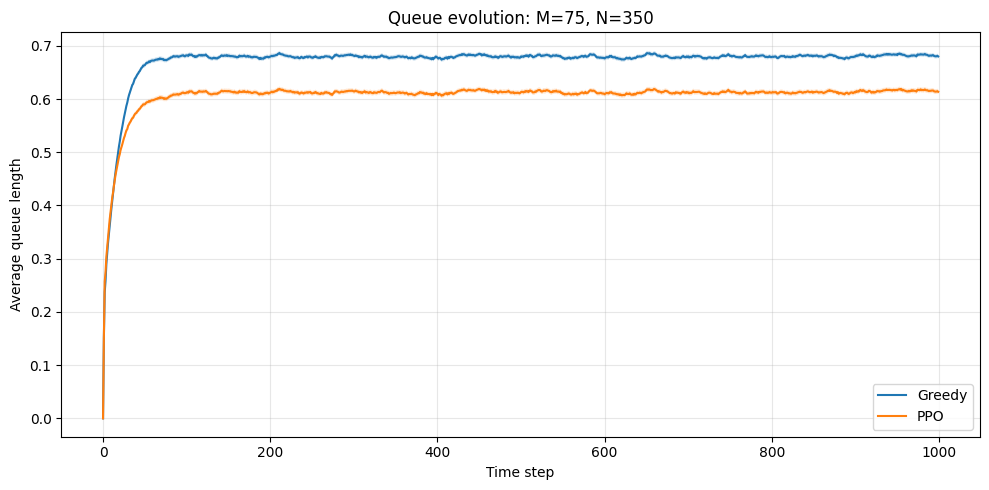

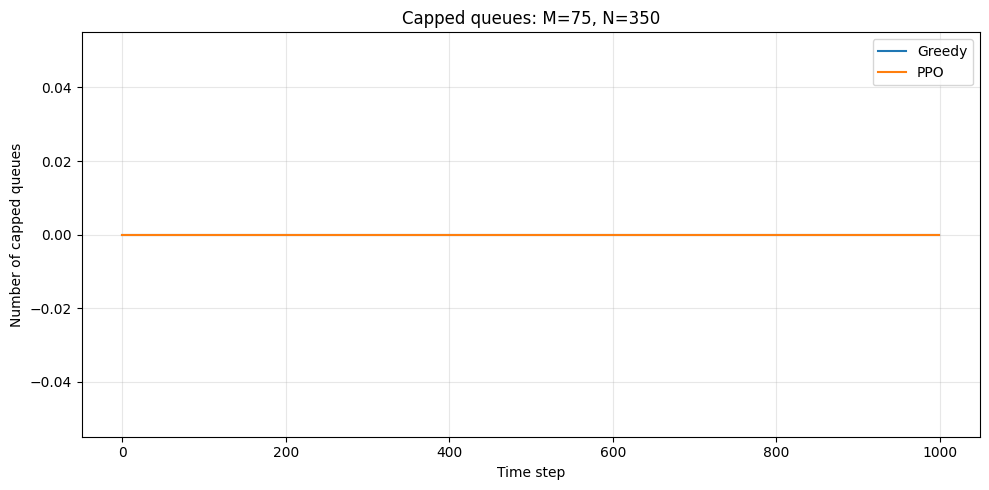

In [19]:
# -------------------------
# Parallel episode worker(s)
# -------------------------
from typing import Tuple
import matplotlib.pyplot as plt

def plot_queue_evolution(greedy_res, ppo_res, T: int, title: str = ""):
    t = np.arange(T)

    plt.figure(figsize=(10, 5))
    plt.plot(t, greedy_res["time_mean"], label="Greedy")
    plt.fill_between(
        t,
        greedy_res["time_ci_lo"],
        greedy_res["time_ci_hi"],
        alpha=0.2
    )

    plt.plot(t, ppo_res["time_mean"], label="PPO")
    plt.fill_between(
        t,
        ppo_res["time_ci_lo"],
        ppo_res["time_ci_hi"],
        alpha=0.2
    )

    plt.xlabel("Time step")
    plt.ylabel("Average queue length")
    plt.title(title if title else "Average queue length over time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_cap_count_evolution(greedy_res, ppo_res, T: int, title: str = ""):
    t = np.arange(T)

    plt.figure(figsize=(10, 5))
    plt.plot(t, greedy_res["cap_time_mean"], label="Greedy")
    plt.fill_between(t, greedy_res["cap_time_ci_lo"], greedy_res["cap_time_ci_hi"], alpha=0.2)

    plt.plot(t, ppo_res["cap_time_mean"], label="PPO")
    plt.fill_between(t, ppo_res["cap_time_ci_lo"], ppo_res["cap_time_ci_hi"], alpha=0.2)

    plt.xlabel("Time step")
    plt.ylabel("Number of capped queues")
    plt.title(title if title else "Capped queues over time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# shuffled_arrival_params = np.random.permutation(env_kwargs["arrival_params"])
eval_env_kwargs = env_kwargs.copy()
# eval_env_kwargs["max_steps_per_run"] = 4_000
# eval_env_kwargs["arrival_params"] = shuffled_arrival_params

greedy_res, ppo_res = compare_policies_mean_q(
    env_kwargs=eval_env_kwargs,
    seed=354,
    T=eval_env_kwargs["max_steps_per_run"],
    num_episodes=500,
    model=model,
)

plot_queue_evolution(
    greedy_res,
    ppo_res,
    T=eval_env_kwargs["max_steps_per_run"],
    title=f"Queue evolution: M={eval_env_kwargs['M']}, N={eval_env_kwargs['N']}"
)

plot_cap_count_evolution(
    greedy_res,
    ppo_res,
    T=eval_env_kwargs["max_steps_per_run"],
    title=f"Capped queues: M={eval_env_kwargs['M']}, N={eval_env_kwargs['N']}"
)

In [ ]:
# !tensorboard --logdir=./tb_queueppo